# Random Forest Flower Classification

Notebook này xây dựng hệ thống Random Forest dựa trên pipeline của bài Softmax: load ảnh → resize 32x32 → chia train/validation/test → flatten/normalize → train Random Forest → tuning → đánh giá test → lưu model.

In [20]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
IMG_SIZE = (32, 32)
DATASET_DIR = 'flower-training'

In [21]:
def load_flower_data(data_dir=DATASET_DIR, img_size=IMG_SIZE):
    X = []
    y = []

    for label, cls in enumerate(CLASSES):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            print(f"Warning: folder not found: {cls_dir}")
            continue

        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                X.append(np.array(img))
                y.append(label)
            except Exception:
                pass

    X = np.array(X).astype('float64')
    y = np.array(y)

    np.random.seed(42)
    idxs = np.random.permutation(len(X))
    X = X[idxs]
    y = y[idxs]
    return X, y

X, y = load_flower_data()
print('Full dataset:', X.shape, y.shape)

Full dataset: (2746, 32, 32, 3) (2746,)


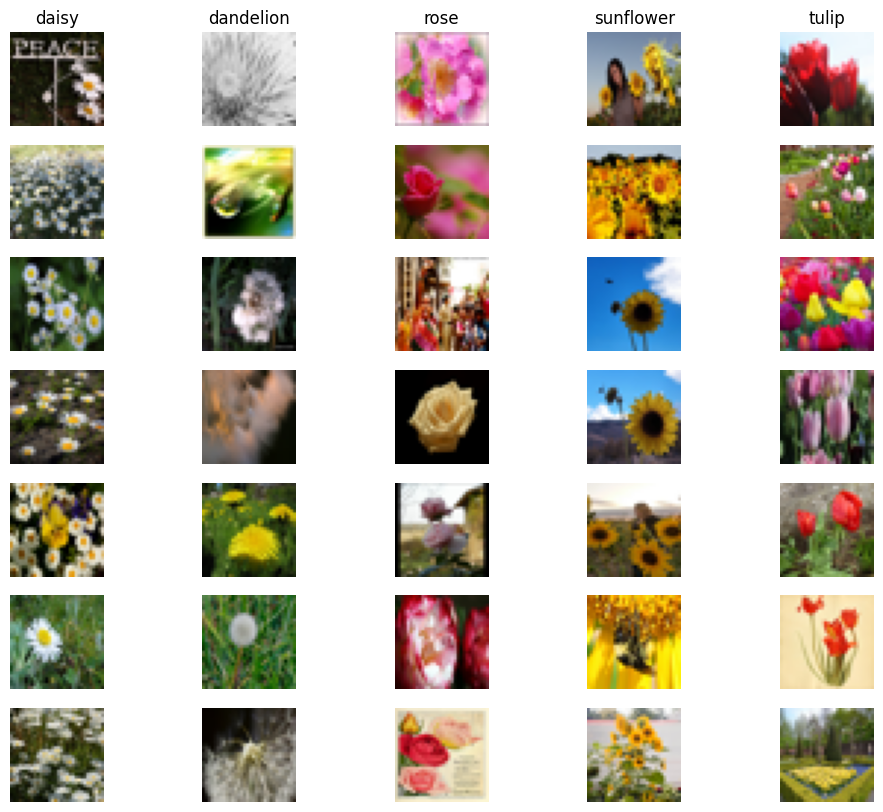

In [22]:
# Visualize samples
num_classes = len(CLASSES)
samples_per_class = 7
plt.figure(figsize=(12, 10))
for label, cls in enumerate(CLASSES):
    idxs = np.flatnonzero(y == label)
    if len(idxs) == 0:
        continue
    idxs = np.random.choice(idxs, min(samples_per_class, len(idxs)), replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + label + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [23]:
# Split data: same purpose as Softmax notebook
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print('Train:', X_train_raw.shape)
print('Validation:', X_val_raw.shape)
print('Test:', X_test_raw.shape)

Train: (1976, 32, 32, 3)
Validation: (220, 32, 32, 3)
Test: (550, 32, 32, 3)


In [24]:
# Preprocessing for Random Forest
# Version 1: use raw pixels like Softmax.
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_val = X_val_raw.reshape(X_val_raw.shape[0], -1)
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1)

# Keep the same normalization idea as Softmax
mean_image = np.mean(X_train, axis=0)
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image

print('Feature shape:', X_train.shape)

Feature shape: (1976, 3072)


In [25]:
# Train one baseline Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)

print('Training accuracy:', accuracy_score(y_train, y_train_pred))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred))

Training accuracy: 0.9994939271255061
Validation accuracy: 0.4863636363636364


In [26]:
# Hyperparameter tuning
results = {}
best_val = -1
best_rf = None

n_estimators_list = [100, 200, 300]
max_depth_list = [None, 10, 20, 30]
min_samples_leaf_list = [1, 2, 4]

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_leaf in min_samples_leaf_list:
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1,
                class_weight='balanced'
            )
            model.fit(X_train, y_train)

            train_acc = accuracy_score(y_train, model.predict(X_train))
            val_acc = accuracy_score(y_val, model.predict(X_val))
            params = (n_estimators, max_depth, min_samples_leaf)
            results[params] = (train_acc, val_acc)

            print(f'n_estimators={n_estimators}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}: train={train_acc:.4f}, val={val_acc:.4f}')

            if val_acc > best_val:
                best_val = val_acc
                best_rf = model

print('Best validation accuracy:', best_val)
print('Best model:', best_rf)

n_estimators=100, max_depth=None, min_samples_leaf=1: train=0.9995, val=0.5091
n_estimators=100, max_depth=None, min_samples_leaf=2: train=0.9995, val=0.5455
n_estimators=100, max_depth=None, min_samples_leaf=4: train=0.9980, val=0.5591
n_estimators=100, max_depth=10, min_samples_leaf=1: train=0.9960, val=0.4818
n_estimators=100, max_depth=10, min_samples_leaf=2: train=0.9944, val=0.5364
n_estimators=100, max_depth=10, min_samples_leaf=4: train=0.9843, val=0.5273
n_estimators=100, max_depth=20, min_samples_leaf=1: train=0.9995, val=0.5227
n_estimators=100, max_depth=20, min_samples_leaf=2: train=0.9995, val=0.5455
n_estimators=100, max_depth=20, min_samples_leaf=4: train=0.9980, val=0.5545
n_estimators=100, max_depth=30, min_samples_leaf=1: train=0.9995, val=0.5091
n_estimators=100, max_depth=30, min_samples_leaf=2: train=0.9995, val=0.5455
n_estimators=100, max_depth=30, min_samples_leaf=4: train=0.9980, val=0.5591
n_estimators=200, max_depth=None, min_samples_leaf=1: train=0.9995, va

In [27]:
# Evaluate the best Random Forest on test data
y_test_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print('Random Forest test accuracy:', test_accuracy)
print('Classification report:')
print(classification_report(y_test, y_test_pred, target_names=CLASSES))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_test_pred))

Random Forest test accuracy: 0.5672727272727273
Classification report:
              precision    recall  f1-score   support

       daisy       0.62      0.53      0.57       100
   dandelion       0.57      0.68      0.62       129
        rose       0.54      0.46      0.50       100
   sunflower       0.67      0.75      0.70        99
       tulip       0.45      0.42      0.43       122

    accuracy                           0.57       550
   macro avg       0.57      0.57      0.57       550
weighted avg       0.56      0.57      0.56       550

Confusion matrix:
[[53 25  8  4 10]
 [11 88  4 13 13]
 [ 9 12 46  5 28]
 [ 4  6  3 74 12]
 [ 9 23 24 15 51]]


In [28]:
# Save best model
joblib.dump({
    'model': best_rf,
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'mean_image': mean_image,
    'use_extra_features': False
}, 'best_random_forest_flower.joblib')
print('Saved: best_random_forest_flower.joblib')

Saved: best_random_forest_flower.joblib


In [30]:
# Predict one new image
def predict_single_image(image_path, model_package_path='best_random_forest_flower.joblib'):
    package = joblib.load(model_package_path)
    model = package['model']
    classes = package['classes']
    img_size = package['img_size']
    mean_image = package['mean_image']

    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)
    arr = np.array(img).astype('float64').reshape(1, -1)
    arr = arr - mean_image

    pred = model.predict(arr)[0]
    prob = model.predict_proba(arr)[0]

    print('Predicted class:', classes[pred])
    for cls, p in zip(classes, prob):
        print(f'{cls}: {p:.4f}')
    return classes[pred], prob

# Example:
# predict_single_image('path/to/your/image.jpg')
predict_single_image('flower-training/sunflower/9558627290_353a14ba0b_m.jpg')

Predicted class: sunflower
daisy: 0.0346
dandelion: 0.0497
rose: 0.0445
sunflower: 0.7962
tulip: 0.0750


('sunflower',
 array([0.03461381, 0.04970488, 0.04446347, 0.79624813, 0.07496972]))

## Concept ngắn

Random Forest trong hệ thống này thay thế phần Softmax Classifier. Ảnh vẫn được resize, flatten và normalize giống notebook Softmax. Khác biệt là Random Forest không học ma trận trọng số W bằng SGD, mà xây nhiều decision trees. Mỗi cây học một phần dữ liệu và đặc trưng khác nhau, sau đó các cây bỏ phiếu để chọn nhãn cuối cùng.